In [1]:
import os
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"

In [2]:
DATA_PATH = "/kaggle/input/datasets/jedidiahangekouakou/grid-corpus-dataset-for-training-lipnet/data"
#/kaggle/input/datasets/jedidiahangekouakou/grid-corpus-dataset-for-training-lipnet/data

In [3]:
import sys
print(sys.executable)

/usr/bin/python3


In [4]:
import tensorflow as tf

print("TF Version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

2026-03-20 17:07:07.364051: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774026427.385399    1030 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774026427.391841    1030 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774026427.410339    1030 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774026427.410359    1030 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774026427.410362    1030 computation_placer.cc:177] computation placer alr

TF Version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)

if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

tf.keras.backend.clear_session()

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
import tensorflow as tf

a = tf.random.normal([1000, 1000])
b = tf.matmul(a, a)

print(b.device)

/job:localhost/replica:0/task:0/device:GPU:0


I0000 00:00:1774026437.258404    1030 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [7]:
import os
print(os.listdir('/kaggle/input/datasets/manvithadutt/lipnet-epoch-43-h5'))

['lipnet_epoch_43.h5']


In [8]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)

if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

print("GPU Ready")

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU Ready


# Installing and Importing Dependencies

In [9]:
import os

os.environ["TF_XLA_FLAGS"] = "--tf_xla_enable_xla_devices=false"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
tf.config.optimizer.set_jit(False)

In [10]:
!pip list

Package                                  Version
---------------------------------------- -------------------
a2a-sdk                                  0.3.23
absl-py                                  1.4.0
accelerate                               1.12.0
access                                   1.1.10.post3
affine                                   2.4.0
aiofiles                                 22.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.3
aiosignal                                1.4.0
aiosqlite                                0.22.1
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.18.1
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
ansicolors                   

In [11]:
!pip install opencv-python matplotlib imageio gdown tensorflow

In [12]:
import os
import cv2
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from typing import List
import imageio

In [13]:
physical_devices = tf.config.list_physical_devices('GPU')
try:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
except:
    pass

# Building the Data Loading Function:

In [14]:
import gdown

In [15]:
def load_video(path):
    frames = []
    cap = cv2.VideoCapture(path)

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Convert to grayscale
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Resize to (140, 46) -> (width, height)
        frame = cv2.resize(frame, (140, 46))

        frames.append(frame)

    cap.release()

    frames = np.array(frames)

    # Add channel dimension
    frames = np.expand_dims(frames, axis=-1)

    return frames

In [16]:
vocab = [x for x in "abcdefghijklmnopqrstuvwxyz'?!123456789 "]

In [17]:
char_to_num = tf.keras.layers.StringLookup(vocabulary=vocab, oov_token="")
num_to_char = tf.keras.layers.StringLookup(vocabulary=char_to_num.get_vocabulary(), oov_token="", invert=True)

print(
    f"the vocabulary is: {char_to_num.get_vocabulary()}"
    f"(size = {char_to_num.vocabulary_size()})"
)

the vocabulary is: ['', np.str_('a'), np.str_('b'), np.str_('c'), np.str_('d'), np.str_('e'), np.str_('f'), np.str_('g'), np.str_('h'), np.str_('i'), np.str_('j'), np.str_('k'), np.str_('l'), np.str_('m'), np.str_('n'), np.str_('o'), np.str_('p'), np.str_('q'), np.str_('r'), np.str_('s'), np.str_('t'), np.str_('u'), np.str_('v'), np.str_('w'), np.str_('x'), np.str_('y'), np.str_('z'), np.str_("'"), np.str_('?'), np.str_('!'), np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'), np.str_('9'), np.str_(' ')](size = 40)


In [18]:
char_to_num(['a','a','r','a','n','a','y'])

<tf.Tensor: shape=(7,), dtype=int64, numpy=array([ 1,  1, 18,  1, 14,  1, 25])>

In [19]:
def load_alignments(path):

    with open(path, 'r') as f:
        lines = f.readlines()

    words = []

    for line in lines:
        parts = line.strip().split()

        if len(parts) >= 3:
            word = parts[2]

            if word != 'sil':
                words.append(word)

    sentence = ' '.join(words)

    # convert to characters
    chars = list(sentence)

    # convert chars to numbers
    encoded = char_to_num(tf.constant(chars)).numpy()

    return encoded

In [20]:
def load_data(path: str):

    if hasattr(path, "numpy"):
        path = path.numpy().decode()
    elif isinstance(path, bytes):
        path = path.decode()

    file_name = path.split('/')[-1].split('.')[0]
    speaker = path.split('/')[-2]

    #video_path = os.path.join('/kaggle/input/datasets/jedidiahangekouakou/grid-corpus-dataset-for-training-lipnet/data', speaker, f'{file_name}.mpg')
    video_path = os.path.join(DATA_PATH, speaker, f"{file_name}.mpg")
    alignment_path = os.path.join(DATA_PATH, speaker, 'align', f'{file_name}.align')

    frames = load_video(video_path)
    alignments = load_alignments(alignment_path)

    return frames, alignments

In [21]:
#test_path = '/content/drive/MyDrive/Classroom/data/alignments/s1/bbwm5s.align'
test_path = '/kaggle/input/datasets/jedidiahangekouakou/grid-corpus-dataset-for-training-lipnet/data/s1_processed/align/bbaf2n.align'


In [22]:
import os

align_path = "/kaggle/input/datasets/jedidiahangekouakou/grid-corpus-dataset-for-training-lipnet/data/s1_processed/align"

print("Align folder exists:", os.path.exists(align_path))
print("Files inside align folder:")
print(os.listdir(align_path)[:10])  # show first 10 files

Align folder exists: True
Files inside align folder:
['bwbh1a.align', 'srbb6p.align', 'pbao8n.align', 'bwag5s.align', 'bwag4n.align', 'lwwm3a.align', 'pgij9s.align', 'bwaa1s.align', 'bgbozp.align', 'bgit5s.align']


In [23]:
tf.convert_to_tensor(test_path).numpy().decode('UTF-8').split('/')[-1].split('.')

['bbaf2n', 'align']

In [24]:
print("bbaf2n.align exists:",
      "bbaf2n.align" in os.listdir(align_path))

bbaf2n.align exists: True


[ 2  9 14 39  2 12 21  5 39  1 20 39  6 39 20 23 15 39 14 15 23]


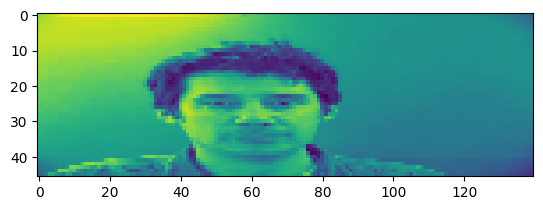

In [25]:
test_path = "/kaggle/input/datasets/jedidiahangekouakou/grid-corpus-dataset-for-training-lipnet/data/s1_processed/bbaf2n.mpg"

frames, alignments = load_data(test_path)

plt.imshow(frames[0])
print(alignments)

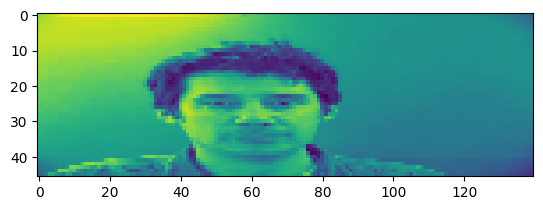

In [26]:
plt.imshow(frames[0])

In [27]:
tf.strings.reduce_join(num_to_char(tf.reshape(alignments, (-1,))))

<tf.Tensor: shape=(), dtype=string, numpy=b'bin blue at f two now'>

In [28]:
def mappable_function(path):

    frames, alignments = tf.py_function(
        load_data,
        [path],
        (tf.float32, tf.int64)
    )

    frames.set_shape([75,46,140,1])
    alignments.set_shape([None])

    return frames, alignments

# Creating Data Pipeline

In [29]:
with tf.device('/CPU:0'):

    data = tf.data.Dataset.list_files('/kaggle/input/datasets/jedidiahangekouakou/grid-corpus-dataset-for-training-lipnet/data/s*/*.mpg')

    data = data.shuffle(34000)

    train = data.take(30000)
    test = data.skip(30000)

    train = train.map(mappable_function, num_parallel_calls=tf.data.AUTOTUNE)
    test = test.map(mappable_function, num_parallel_calls=tf.data.AUTOTUNE)

    train = train.padded_batch(
        4,
        padded_shapes=([75,46,140,1],[None])
    )

    test = test.padded_batch(
        4,
        padded_shapes=([75,46,140,1],[None])
    )

    train = train.prefetch(tf.data.AUTOTUNE)
    test = test.prefetch(tf.data.AUTOTUNE)


In [30]:
frames, alignments = train.as_numpy_iterator().next()

In [31]:
for x, y in train.take(1):
    print(x.shape)
    print(y.shape)

(4, 75, 46, 140, 1)
(4, 28)


In [32]:
len(frames)

4

In [33]:
print(type(test))

<class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>


In [34]:
val = list(test.take(1))[0]

In [35]:
tf.strings.reduce_join([num_to_char(word) for word in val[1][0]])

<tf.Tensor: shape=(), dtype=string, numpy=b'lay red in a seven please'>

# Designing the neural network

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Conv3D, LSTM, Dense, Dropout, Bidirectional, MaxPool3D, Activation, Reshape, SpatialDropout3D, BatchNormalization, TimeDistributed, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, TensorBoard

In [37]:
model = Sequential([

Input(shape=(75,46,140,1)),

Conv3D(128,3,padding='same'),
BatchNormalization(),
Activation('relu'),
MaxPool3D((1,2,2)),

Conv3D(256,3,padding='same'),
BatchNormalization(),
Activation('relu'),
MaxPool3D((1,2,2)),

Conv3D(75,3,padding='same'),
BatchNormalization(),
Activation('relu'),
MaxPool3D((1,2,2)),

TimeDistributed(Flatten()),

Bidirectional(LSTM(128, return_sequences=True)),
Dropout(0.5),

Bidirectional(LSTM(128, return_sequences=True)),
Dropout(0.5),

Dense(char_to_num.vocabulary_size()+1, activation="softmax")

])

In [38]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 75, 46, 140,    │         3,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 75, 46, 140,    │           512 │
│ (BatchNormalization)            │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 75, 46, 140,    │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 75, 23, 70,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 75, 23, 70,     │       884,992 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 23, 70,     │         1,024 │
│ (BatchNormalization)            │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 75, 23, 70,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 75, 11, 35,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 75, 11, 35, 75) │       518,475 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 11, 35, 75) │           300 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 75, 11, 35, 75) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 75, 5, 17, 75)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 75, 6375)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 75, 256)        │     6,660,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 75, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 75, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 75, 41)         │        10,537 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,473,760 (32.32 MB)

 Trainable params: 8,472,842 (32.32 MB)

 Non-trainable params: 918 (3.59 KB)

In [39]:
print(val[0].shape)

(4, 75, 46, 140, 1)


In [40]:
y_hat = model.predict(val[0])

I0000 00:00:1774026583.793586    1087 cuda_dnn.cc:529] Loaded cuDNN version 91002


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [41]:
tf.strings.reduce_join([num_to_char(x) for x in tf.argmax(y_hat[0], axis = 1)])

<tf.Tensor: shape=(), dtype=string, numpy=b'                                                                           '>

In [42]:
tf.strings.reduce_join([num_to_char(tf.argmax(x)) for x in y_hat[0]])

<tf.Tensor: shape=(), dtype=string, numpy=b'                                                                           '>

In [43]:
model.input_shape

(None, 75, 46, 140, 1)

In [44]:
model.output_shape

(None, 75, 41)

# Setting Up Training Options and Training

In [45]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

print("GPU Ready")

GPU Ready


In [46]:
import math

def scheduler(epoch, lr):
    if epoch < 50:
        return float(lr)
    else:
        return float(lr * math.exp(-0.1))#If the epoch is 30 or greater, it returns the learning rate multiplied by tf.math.exp(-0.1) (approximately 0.9), effectively decreasing the learning rate.

In [47]:
def CTCLoss(y_true, y_pred):
    batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
    label_length = tf.cast(tf.shape(y_true)[1], dtype="int64")

    input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
    label_length = label_length * tf.ones(shape=(batch_len, 1), dtype="int64")

    loss = tf.keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)
    return loss

In [48]:
class ProduceExample(tf.keras.callbacks.Callback):
    def __init__(self, dataset):
        self.dataset = dataset

    def on_epoch_end(self, epoch, logs=None):
        for data in self.dataset.take(1):
            yhat = self.model.predict(data[0])
            input_len = tf.ones(yhat.shape[0]) * yhat.shape[1]

            decoded = tf.keras.backend.ctc_decode(
                  yhat,
                  input_length=input_len,
                  greedy=False
              )[0][0].numpy()

            for x in range(len(yhat)):
                print('Original:',
                      tf.strings.reduce_join(
                          num_to_char(data[1][x])
                      ).numpy().decode('utf-8'))
                print('Prediction:',
                      tf.strings.reduce_join(
                          num_to_char(decoded[x])
                      ).numpy().decode('utf-8'))
                print('~'*100)

In [49]:

model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 0.0001), loss = CTCLoss)

In [50]:
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    '/kaggle/working/checkpoint.weights.h5',
    monitor='loss',
    save_weights_only=True
)

In [51]:
schedule_callback = LearningRateScheduler(scheduler)

In [52]:
import os
os.makedirs("/kaggle/working/lipnet_checkpoints", exist_ok=True)

In [53]:
example_callback = ProduceExample(test)

In [54]:
from tensorflow.keras.callbacks import Callback

class SaveCheckpointEvery5Epochs(Callback):
    def on_epoch_end(self, epoch, logs=None):
        #if (epoch + 1) % 2 == 0:
            path = f"/kaggle/working/lipnet_checkpoints/lipnet_epoch_{epoch+1}.h5"
            self.model.save(path)
            print(f"Checkpoint saved: {path}")

In [57]:
model.load_weights('/kaggle/input/datasets/manvithadutt/lipnet-epoch-50-h5/lipnet_epoch_50.h5')

In [ ]:
model.fit(
    train,
    validation_data=test,
    epochs=46,
    initial_epoch=43,
    callbacks=[SaveCheckpointEvery5Epochs(), schedule_callback, example_callback]
)

In [ ]:
model.load_weights('/kaggle/working/lipnet_checkpoints/lipnet_epoch_46.h5')

In [ ]:
model.fit(
    train,
    validation_data=test,
    epochs=50,
    initial_epoch=46,
    callbacks=[SaveCheckpointEvery5Epochs(), schedule_callback, example_callback]
)

In [ ]:
model.fit(train,validation_data=test,epochs=35,callbacks=[SaveCheckpointEvery5Epochs(), schedule_callback,example_callback])

In [ ]:
!ls -R /kaggle/working

In [ ]:
model.load_weights('/kaggle/working/lipnet_checkpoints/lipnet_epoch_31.h5')

model.fit(
    train,
    validation_data=test,
    epochs=33,
    initial_epoch=31,
    callbacks=[SaveCheckpointEvery5Epochs(), schedule_callback, example_callback]
)

In [ ]:
import os

for root, dirs, files in os.walk('/kaggle/working'):
    print("FOLDER:", root)
    for f in files:
        print("  FILE:", f)

# Making a prediction

In [59]:
import os
print(os.listdir('/kaggle/working/lipnet_checkpoints'))

[]


In [60]:
from IPython.display import display
from ipywidgets import FileUpload

uploader = FileUpload()
display(uploader)

FileUpload(value=(), description='Upload')

In [63]:
model.load_weights('/kaggle/input/datasets/manvithadutt/lipnet-epoch-50-h5/lipnet_epoch_50.h5')

In [64]:
test_data = test

In [65]:
batch = next(iter(test_data))

In [66]:
sample = next(iter(test_data))

In [67]:
yhat = model.predict(sample[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 841ms/step


In [68]:
print('~'*100, 'REAL TEXT')
[tf.strings.reduce_join([num_to_char(word) for word in sentence]) for sentence in sample[1]]

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ REAL TEXT


[<tf.Tensor: shape=(), dtype=string, numpy=b'lay blue at j two again'>,
 <tf.Tensor: shape=(), dtype=string, numpy=b'bin white in z six please'>,
 <tf.Tensor: shape=(), dtype=string, numpy=b'lay blue at a six now'>,
 <tf.Tensor: shape=(), dtype=string, numpy=b'place green at a six please'>]

In [69]:
input_len = np.ones(yhat.shape[0]) * yhat.shape[1]

decoded = tf.keras.backend.ctc_decode(
    yhat,
    input_length=input_len,
    greedy=False,      # 🔥 use beam search
    beam_width=10
)[0][0].numpy()

In [70]:
print('~'*100, 'PREDICTIONS')
[tf.strings.reduce_join([num_to_char(word) for word in sentence]) for sentence in decoded]

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ PREDICTIONS


[<tf.Tensor: shape=(), dtype=string, numpy=b'lay blue at c two again'>,
 <tf.Tensor: shape=(), dtype=string, numpy=b'bin white in z six please'>,
 <tf.Tensor: shape=(), dtype=string, numpy=b'lay blue wit x six now'>,
 <tf.Tensor: shape=(), dtype=string, numpy=b'place gren an h six please'>]

# Testing on a video

In [72]:
sample = load_data(tf.convert_to_tensor('/kaggle/input/datasets/jedidiahangekouakou/grid-corpus-dataset-for-training-lipnet/data/s12_processed/bbae1n.mpg'))

In [73]:
yhat = model.predict(tf.expand_dims(sample[0], axis = 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [74]:
yhat.shape

(1, 75, 41)

In [75]:
print('~'*100, 'REAL TEXT')
[tf.strings.reduce_join([num_to_char(word) for word in sentence]) for sentence in [sample[1]]]

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ REAL TEXT


[<tf.Tensor: shape=(), dtype=string, numpy=b'bin blue at e one now'>]

In [76]:
decoded = tf.keras.backend.ctc_decode(yhat, input_length=[75], greedy=True)[0][0].numpy()

In [77]:
print('~'*100, 'PREDICTIONS')
[tf.strings.reduce_join([num_to_char(word) for word in sentence]) for sentence in decoded]

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ PREDICTIONS


[<tf.Tensor: shape=(), dtype=string, numpy=b'bin blue in z one now'>]

In [79]:
def wer_manual(ref, hyp):
    r = ref.split()
    h = hyp.split()
    
    dp = [[0] * (len(h)+1) for _ in range(len(r)+1)]
    
    for i in range(len(r)+1):
        dp[i][0] = i
    for j in range(len(h)+1):
        dp[0][j] = j

    for i in range(1, len(r)+1):
        for j in range(1, len(h)+1):
            if r[i-1] == h[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(
                    dp[i-1][j],    # deletion
                    dp[i][j-1],    # insertion
                    dp[i-1][j-1]   # substitution
                )
    
    return dp[len(r)][len(h)] / len(r)

In [80]:
def cer_manual(ref, hyp):
    r = list(ref)
    h = list(hyp)
    
    dp = [[0] * (len(h)+1) for _ in range(len(r)+1)]
    
    for i in range(len(r)+1):
        dp[i][0] = i
    for j in range(len(h)+1):
        dp[0][j] = j

    for i in range(1, len(r)+1):
        for j in range(1, len(h)+1):
            if r[i-1] == h[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(
                    dp[i-1][j],
                    dp[i][j-1],
                    dp[i-1][j-1]
                )
    
    return dp[len(r)][len(h)] / len(r)

In [81]:
real = "bin blue at e one now"
pred = "bin blue in z one now"

print("WER:", wer_manual(real, pred))
print("CER:", cer_manual(real, pred))

WER: 0.3333333333333333
CER: 0.14285714285714285


In [89]:
def word_accuracy(ref, hyp):
    return 1 - wer_manual(ref, hyp)

In [90]:
def char_accuracy(ref, hyp):
    return 1 - cer_manual(ref, hyp)

In [91]:
from collections import Counter

def bleu_score(ref, hyp):
    ref_words = ref.split()
    hyp_words = hyp.split()
    
    ref_count = Counter(ref_words)
    hyp_count = Counter(hyp_words)
    
    overlap = sum(min(ref_count[w], hyp_count[w]) for w in hyp_count)
    
    return overlap / len(hyp_words)

In [92]:
def edit_distance(ref, hyp):
    r = list(ref)
    h = list(hyp)
    
    dp = [[0]*(len(h)+1) for _ in range(len(r)+1)]
    
    for i in range(len(r)+1): dp[i][0] = i
    for j in range(len(h)+1): dp[0][j] = j

    for i in range(1, len(r)+1):
        for j in range(1, len(h)+1):
            if r[i-1] == h[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(
                    dp[i-1][j],
                    dp[i][j-1],
                    dp[i-1][j-1]
                )
    return dp[-1][-1]

In [95]:
real = "bin blue at e one now"
pred = "bin blue in z one now"


print("WER:", wer_manual(real, pred))
print("CER:", cer_manual(real, pred))
print("Word Accuracy:", word_accuracy(real, pred))
print("Char Accuracy:", char_accuracy(real, pred))
#print("Exact Match:", exact_match(real, pred))
print("BLEU:", bleu_score(real, pred))
print("Edit Distance:", edit_distance(real, pred))

WER: 0.3333333333333333
CER: 0.14285714285714285
Word Accuracy: 0.6666666666666667
Char Accuracy: 0.8571428571428572
BLEU: 0.6666666666666666
Edit Distance: 3


In [ ]:
import gradio as gr
import tensorflow as tf

In [99]:
import gradio as gr
import tensorflow as tf

def predict(video):
    frames = load_video(video)
    frames = tf.expand_dims(frames, axis=0)

    yhat = model.predict(frames)

    decoded = tf.keras.backend.ctc_decode(
        yhat,
        input_length=[yhat.shape[1]],
        greedy=True
    )[0][0].numpy()

    prediction = tf.strings.reduce_join(
        [num_to_char(word) for word in decoded]
    )

    return prediction.numpy().decode("utf-8")


# 🔥 FIX IS HERE
gr.Interface(
    fn=predict,
    inputs=gr.Video(),
    outputs="text"
).launch(share=False)

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
